# K-Nearest Neighbors — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

Notice what this notebook does NOT contain: no loss function, no gradients, no training loop. KNN is learning as **memory + a ruler** (README §3.3) — the contrast lesson to 01 and 02.

In [1]:
# Block 1 — Imports. Still NumPy only.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(11)

## Block 2 — Look at the data BEFORE modeling *(README §1)*

KNN's belief: **similar things share a class** — same-class fruits should form clusters. Three classes this time; KNN won't even notice (README §1).

   weight_g  sweetness_brix   fruit
0      97.8            1.90   lemon
1     102.3            3.48   lemon
2     178.2           12.86   apple
3     161.2           10.71  orange
4     199.6            8.91  orange 

counts: {'lemon': 60, 'apple': 60, 'orange': 60}


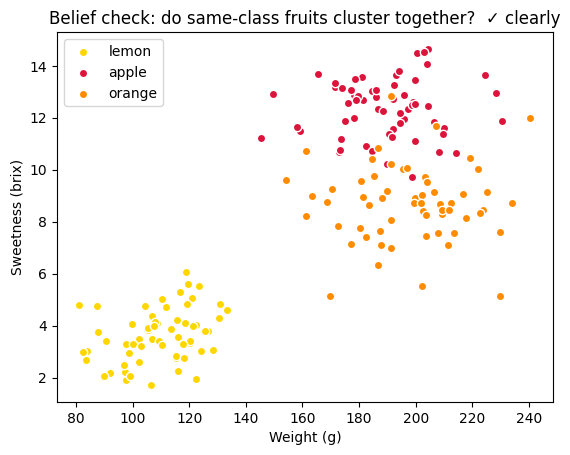

In [2]:
df = pd.read_csv("data/fruit_data.csv")
print(df.head(), f"\n\ncounts: {df.fruit.value_counts().to_dict()}")

classes = ["lemon", "apple", "orange"]
X = df[["weight_g", "sweetness_brix"]].values
y = np.array([classes.index(f) for f in df.fruit])   # labels as 0/1/2 — README §0 (lesson 02)

colors = {"lemon": "gold", "apple": "crimson", "orange": "darkorange"}
for ci, nm in enumerate(classes):
    plt.scatter(X[y==ci,0], X[y==ci,1], color=colors[nm], label=nm, edgecolor="white")
plt.xlabel("Weight (g)"); plt.ylabel("Sweetness (brix)"); plt.legend()
plt.title("Belief check: do same-class fruits cluster together?  ✓ clearly")
plt.show()

## Block 3 — Feature scaling: NOT optional here *(README §2.2)*

In lessons 01–02, skipping scaling made training slow. In KNN it silently changes the answers: weight (grams, ~100–250) would drown sweetness (~1–16) and the ruler would go blind to taste. Scaling *defines* what "similar" means.

In [3]:
mu, sd = X.mean(axis=0), X.std(axis=0)
Xs = (X - mu) / sd
print("Before scaling, weight's share of a typical squared distance:")
q = X[0]
share = np.mean((X[1:,0]-q[0])**2 / ((X[1:]-q)**2).sum(axis=1))
print(f"  ~{share:.0%}  ← the ruler was measuring ONE feature (README §2.2)")

Before scaling, weight's share of a typical squared distance:
  ~97%  ← the ruler was measuring ONE feature (README §2.2)


## Block 4 — The ruler *(README §3.1)*

Pythagoras with as many legs as features: square the differences (kills the sign — lesson 01 §2.2's trick again), sum, square-root.

In [4]:
def distances(Xs, query):
    """README §3.1 — Euclidean distance from one query to EVERY stored example."""
    return np.sqrt(((Xs - query) ** 2).sum(axis=1))

## Block 5 — The entire model, for one mystery fruit *(README §3.2)*

Sort by distance, keep K, count votes. Watch it happen by hand — this is the whole algorithm.

In [5]:
mystery = np.array([192.0, 9.3])                  # weight 192g, sweetness 9.3 — apple or orange?
mystery_s = (mystery - mu) / sd                    # measure with the SAME ruler (same scaling)

K = 5
d = distances(Xs, mystery_s)
nearest = np.argsort(d)[:K]                        # indices of the K most similar fruits

print("The", K, "nearest neighbors:")
for i in nearest:
    print(f"  {classes[y[i]]:7s}  weight={X[i,0]:6.1f}g  sweetness={X[i,1]:5.2f}  distance={d[i]:.3f}")

votes = np.bincount(y[nearest], minlength=3)
print("\nVotes:", dict(zip(classes, votes)))
print("Prediction:", classes[votes.argmax()], " ← majority vote. No training ever happened (README §3.3)")

The 5 nearest neighbors:
  orange   weight= 189.8g  sweetness= 9.18  distance=0.060
  orange   weight= 188.2g  sweetness= 8.91  distance=0.135
  apple    weight= 198.8g  sweetness= 9.72  distance=0.192
  orange   weight= 185.4g  sweetness= 9.76  distance=0.195
  orange   weight= 199.6g  sweetness= 8.91  distance=0.204

Votes: {'lemon': np.int64(0), 'apple': np.int64(1), 'orange': np.int64(4)}
Prediction: orange  ← majority vote. No training ever happened (README §3.3)


## Block 6 — The train/test split: the new rule of the course *(README §5)*

> **From now on, no score counts unless measured on data the model never saw.**

We hide 20% of the fruits. The training set is the textbook; the test set is the exam.

In [6]:
idx = np.random.permutation(len(y))
cut = int(0.8 * len(y))
tr, te = idx[:cut], idx[cut:]

# Scale using TRAINING statistics only — the exam stays sealed (README §9, mistake 3)
mu_tr, sd_tr = X[tr].mean(axis=0), X[tr].std(axis=0)
Xtr, Xte = (X[tr]-mu_tr)/sd_tr, (X[te]-mu_tr)/sd_tr
ytr, yte = y[tr], y[te]
print(f"memorized (train): {len(tr)} fruits   |   hidden exam (test): {len(te)} fruits")

def knn_predict(Xtr, ytr, Xq, k):
    """README §3.2, vectorized over many query points."""
    d = np.sqrt(((Xq[:, None, :] - Xtr[None, :, :]) ** 2).sum(axis=2))  # every query × every stored example
    nearest = np.argsort(d, axis=1)[:, :k]
    return np.array([np.bincount(ytr[row], minlength=3).argmax() for row in nearest])

memorized (train): 144 fruits   |   hidden exam (test): 36 fruits


## Block 7 — Grade it on the exam *(README §5 — lesson 02's metrics, now 3×3)*

In [7]:
pred = knn_predict(Xtr, ytr, Xte, k=5)
acc = np.mean(pred == yte)
print(f"Test accuracy (K=5): {acc:.0%}\n")

cm = np.zeros((3,3), dtype=int)
for t, p in zip(yte, pred):
    cm[t, p] += 1
print("Confusion matrix (rows = truth, cols = predicted)")
print("           " + "".join(f"{c:>8s}" for c in classes))
for i, row in enumerate(cm):
    print(f"{classes[i]:>10s} " + "".join(f"{v:8d}" for v in row))
print("\nRead it like lesson 02 §5 — off-diagonal cells are the mistakes; note WHICH pairs get confused.")

Test accuracy (K=5): 97%

Confusion matrix (rows = truth, cols = predicted)
              lemon   apple  orange
     lemon       11       0       0
     apple        0      11       0
    orange        0       1      13

Read it like lesson 02 §5 — off-diagonal cells are the mistakes; note WHICH pairs get confused.


## Block 8 — THE picture: the K-sweep *(README §4 + §5)*

Train accuracy and test accuracy, for K = 1…60. Train starts at 100% (K=1 is self-matching — a guaranteed, meaningless score) and falls; test rises, peaks, falls. **The gap between the curves is overfitting, made visible.** You'll draw this picture, with different knob names, for every model from here on.

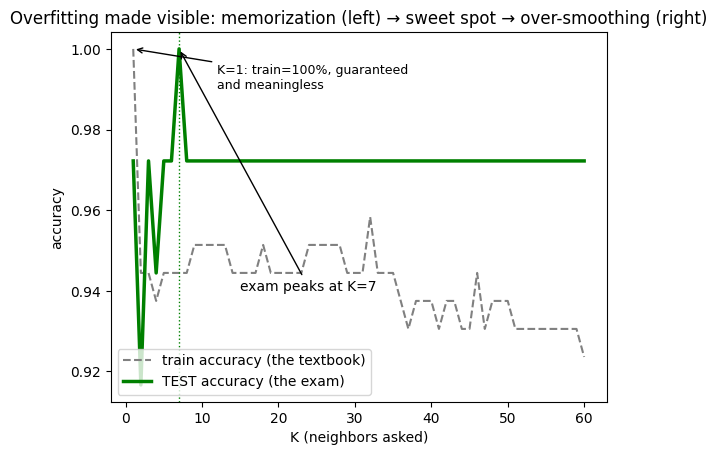

Honest choice: K = 7, decided by the exam, never the textbook (README §5)


In [8]:
ks = range(1, 61)
train_acc = [np.mean(knn_predict(Xtr, ytr, Xtr, k) == ytr) for k in ks]
test_acc  = [np.mean(knn_predict(Xtr, ytr, Xte, k) == yte) for k in ks]

plt.plot(ks, train_acc, label="train accuracy (the textbook)", color="gray", ls="--")
plt.plot(ks, test_acc, label="TEST accuracy (the exam)", color="green", lw=2.5)
best_k = list(ks)[int(np.argmax(test_acc))]
plt.axvline(best_k, color="green", ls=":", lw=1)
plt.annotate(f"exam peaks at K={best_k}", xy=(best_k, max(test_acc)), xytext=(best_k+8, max(test_acc)-0.06),
             arrowprops=dict(arrowstyle="->"))
plt.annotate("K=1: train=100%, guaranteed\nand meaningless", xy=(1, 1.0), xytext=(12, 0.99),
             arrowprops=dict(arrowstyle="->"), fontsize=9)
plt.xlabel("K (neighbors asked)"); plt.ylabel("accuracy"); plt.legend(loc="lower left")
plt.title("Overfitting made visible: memorization (left) → sweet spot → over-smoothing (right)")
plt.show()
print(f"Honest choice: K = {best_k}, decided by the exam, never the textbook (README §5)")

## Block 9 — Break it on purpose: skip the scaling *(README §2.2)*

Same code, raw features. No error message appears — accuracy just quietly drops. The most dangerous kind of bug.

In [9]:
pred_raw = knn_predict(X[tr].astype(float), ytr, X[te].astype(float), k=5)
print(f"Test accuracy WITH scaling    : {np.mean(pred == yte):.0%}")
print(f"Test accuracy WITHOUT scaling : {np.mean(pred_raw == yte):.0%}")
print("\nNo crash, no warning — the ruler simply went blind to sweetness (README §2.2).")

Test accuracy WITH scaling    : 97%
Test accuracy WITHOUT scaling : 83%

No crash, no warning — the ruler simply went blind to sweetness (README §2.2).


## Block 10 — Where does it fail? *(README §6)*

Classification edition of the residual habit: look at the misclassified fruits. Expect them in the apple/orange border zone — where the classes genuinely overlap, not where the model is broken.

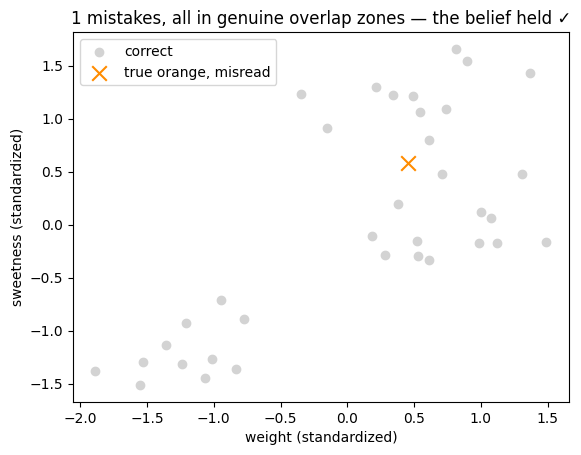

In [10]:
wrong = pred != yte
plt.scatter(Xte[~wrong,0], Xte[~wrong,1], c="lightgray", label="correct")
for ci, nm in enumerate(classes):
    m = wrong & (yte == ci)
    if m.any():
        plt.scatter(Xte[m,0], Xte[m,1], color=colors[nm], marker="x", s=110,
                    label=f"true {nm}, misread")
plt.xlabel("weight (standardized)"); plt.ylabel("sweetness (standardized)"); plt.legend()
plt.title(f"{wrong.sum()} mistakes, all in genuine overlap zones — the belief held ✓")
plt.show()

---
## What you now own

- A second philosophy of learning: memory + similarity, zero training — and its price (every prediction scans everything)
- Distance as a ruler, and why scaling *defines* similarity rather than just speeding things up
- **Overfitting and the train/test split** — the K-sweep picture you'll redraw for every future model
- The curse of dimensionality: why "nearest" stops meaning anything in high dimensions

**Next:** `knn_with_library.ipynb` to verify against sklearn — then folder `04-naive-bayes`, learning as counting evidence.